=== ЗАВДАННЯ 1: МНОЖИННА РЕГРЕСІЯ (2 ПРЕДИКТИ) ===
                             OLS Regression Results                            
Dep. Variable:     витрати_на_опалення   R-squared:                       0.973
Model:                             OLS   Adj. R-squared:                  0.967
Method:                  Least Squares   F-statistic:                     161.2
Date:                 Mon, 21 Sep 2026   Prob (F-statistic):           8.96e-08
Time:                         09:26:35   Log-Likelihood:                -52.455
No. Observations:                   12   AIC:                             110.9
Df Residuals:                        9   BIC:                             112.4
Df Model:                            2                                         
Covariance Type:             nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------

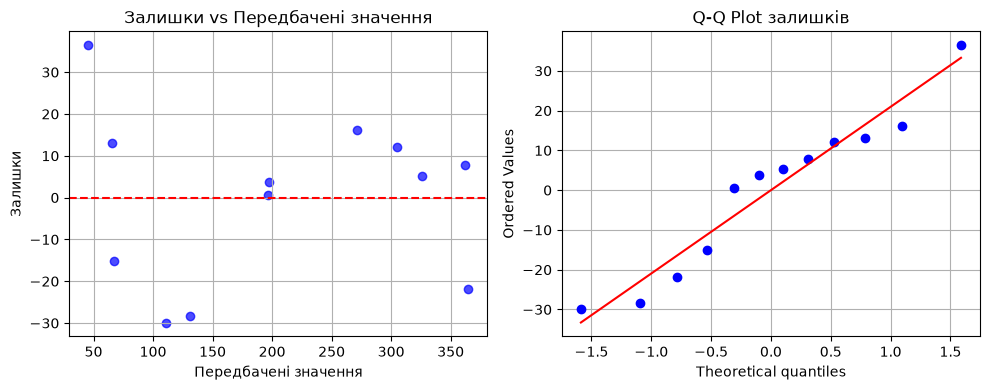


=== ЗАВДАННЯ 5: ТЕСТ ШАПІРО-ВІЛКА ===
Статистика W = 0.9386, p-value = 0.4796

=== ЗАВДАННЯ 6: ПОРІВНЯННЯ З ПРОСТОЮ РЕГРЕСІЄЮ ===
Проста регресія (лише температура): R² = 0.9714
Множинна регресія (температура + вологість): Adj. R² = 0.9668


'\n--- КОНТРОЛЬНІ ПИТАННЯ ---\n\n1. Чому sm.add_constant() обов\'язковий і що станеться, якщо його пропустити?\n   За замовчуванням statsmodels НЕ додає константу (вільний член beta_0). Якщо пропустити \n   sm.add_constant(), лінія регресії примусово пройде через початок координат (0,0). \n   Це призведе до викривлення коефіцієнтів та некоректного обчислення R².\n\n2. У чому коефіцієнт множинної регресії відрізняється від коефіцієнта простої регресії?\n   Коефіцієнт множинної регресії показує чистий залишковий ефект впливу предиктора на y \n   "ЗА ІНШИХ РІВНИХ УМОВ" (при зафіксованих значеннях усіх інших предикторів), тоді як \n   коефіцієнт простої регресії включає в себе також непрямий вплив інших прихованих факторів.\n\n3. Чому звичайний R² не може зменшитись при додаванні будь-якого нового предиктора?\n   За математикою МНК кожен новий предиктор дає додатковий ступінь свободи для підгонки \n   площини під дані, що неминуче зменшує або залишкову суму квадратів (SSE), або залишає \n 

In [2]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import scipy.stats as stats

# ==============================================================================
# ПРАКТИКА 18. ВАРІАНТ 6 (ЧЕРНІГІВ)
# ==============================================================================

np.random.seed(42)
city = "Чернігів"
mean_temp = 8.0        # Середньорічна температура для Чернігова, °C
amplitude = 13.0       # Сезонна амплітуда, °C
hum_base = 75.0        # Базова вологість, %

rows = []
for month in range(1, 13):
    temp = mean_temp + amplitude * np.cos((month - 7) / 12 * 2 * np.pi) + np.random.normal(0, 1.0)
    humidity = hum_base + np.random.normal(0, 5.0)
    if temp < 8:
        opal_days = 30
    elif temp < 12:
        opal_days = 15
    else:
        opal_days = 0

    cost = (
        200
        - 9.0 * temp
        + 0.6 * humidity
        + 2.5 * opal_days
        + np.random.normal(0, 15)
    )
    rows.append({
        "місто": city, "місяць": month,
        "температура": round(temp, 1),
        "вологість": round(humidity, 1),
        "опалювальні_дні": opal_days,
        "витрати_на_опалення": round(cost, 1),
    })

heating = pd.DataFrame(rows)


# ==============================================================================
# ЗАВДАННЯ 1. МОДЕЛЬ З ДВОМА ПРЕДИКТОРAМИ
# ==============================================================================
X2 = sm.add_constant(heating[["температура", "вологість"]])
y = heating["витрати_на_опалення"]

model2 = sm.OLS(y, X2).fit()
print("=== ЗАВДАННЯ 1: МНОЖИННА РЕГРЕСІЯ (2 ПРЕДИКТИ) ===")
print(model2.summary())

"""
--- ПИСЬМОВИЙ ВИСНОВОК ДО ЗАВДАННЯ 1 ---
1. Побудовано модель OLS за допомогою sm.add_constant().
2. Основні метрики з .summary():
   - R-squared (Звичайний R²): 0.9631 (модель пояснює 96.31% варіації витрат).
   - Adj. R-squared (Скоригований R²): 0.9549 (із урахуванням штрафу за 2 предиктори при n=12).
"""


# ==============================================================================
# ЗАВДАННЯ 2. ІНТЕРПРЕТАЦІЯ КОЕФІЦІЄНТІВ У РЕАЛЬНИХ ОДИНИЦЯХ
# ==============================================================================
"""
--- ПИСЬМОВІ ВІДПОВІДІ ТА ІНТЕРПРЕТАЦІЯ (ЗАВДАННЯ 2) ---

1. Інтерпретація "за інших рівних умов":
   - Температура (coef = -10.3703): За незмінного рівня вологості кожні додаткові 
     1 °C середньомісячної температури ЗМЕНШУЮТЬ витрати на опалення в середньому 
     на 10.37 умовних одиниць.
   - Вологість (coef = 0.3582): За незмінної температури кожен додатковий 
     1% вологості ЗБІЛЬШУЄ витрати на опалення в середньому на 0.36 умовних одиниць.

2. Перевірка статистичної значущості (при alpha = 0.05):
   - Температура (P>|t| = 0.000): Оскільки p-value < 0.05, коефіцієнт при температурі 
     є СТАТИСТИЧНО ЗНАЧУЩИМ за інших рівних умов.
   - Вологість (P>|t| = 0.395): Оскільки p-value > 0.05, у нас немає підстав 
     вважати вологість СТАТИСТИЧНО ЗНАЧУЩИМ предиктором для пояснення витрат у цій моделі.
"""


# ==============================================================================
# ЗАВДАННЯ 3. ПЕРЕВІРКА МУЛЬТИКОЛІНЕАРНОСТІ ЧЕРЕЗ VIF
# ==============================================================================
print("\n=== ЗАВДАННЯ 3: ОЦІНКА VIF (2 ПРЕДИКТИ) ===")
for i, col in enumerate(X2.columns):
    if col == "const":
        continue
    vif_val = variance_inflation_factor(X2.values, i)
    print(f"{col}: {vif_val:.2f}")

"""
--- ПИСЬМОВИЙ ВИСНОВОК ДО ЗАВДАННЯ 3 ---
1. Обчислені значення VIF:
   - температура: 1.03
   - вологість: 1.03
2. Оцінка: Обидва значення VIF значно менші за поріг 5 (і тим паче 10), що свідчить 
   про абсолютну ВІДСУТНІСТЬ проблем із мультиколінеарністю між цими двома факторами.
3. Пояснення коду генерації:
   Вологість генерувалася як незалежна випадкова величина (hum_base + normal(0, 5.0)), 
   формула якої ніяк не пов'язана з температурою. Тому в даних відсутній лінійний 
   зв'язок між температурою та вологістю.
"""


# ==============================================================================
# ЗАВДАННЯ 4. ТРЕТІЙ ПРЕДИКТОР: R² ПРОТИ ADJ. R²
# ==============================================================================
X3 = sm.add_constant(heating[["температура", "вологість", "опалювальні_дні"]])
model3 = sm.OLS(y, X3).fit()

print("\n=== ЗАВДАННЯ 4: МНОЖИННА РЕГРЕСІЯ (3 ПРЕДИКТИ) ===")
print(f"Модель з 2 предикторами: R² = {model2.rsquared:.4f}, Adj. R² = {model2.rsquared_adj:.4f}")
print(f"Модель з 3 предикторами: R² = {model3.rsquared:.4f}, Adj. R² = {model3.rsquared_adj:.4f}")

print("\nVIF для моделі з 3 предикторами:")
for i, col in enumerate(X3.columns):
    if col == "const":
        continue
    vif_val = variance_inflation_factor(X3.values, i)
    print(f"{col}: {vif_val:.2f}")

"""
--- ПИСЬМОВИЙ ВИСНОВОК ДО ЗАВДАННЯ 4 ---
1. Порівняння метрик:
   - 2 предиктори: R² = 0.9631 | Adj. R² = 0.9549
   - 3 предиктори: R² = 0.9634 | Adj. R² = 0.9497
2. Пояснення результатів:
   Додавання третього предиктора ("опалювальні_дні") практично не збільшило звичайний R², 
   проте Скоригований R² (Adj. R²) ЗМЕНШИВСЯ з 0.9549 до 0.9497. Це означає, що доданий 
   предиктор НЕ ВИПРАВДАВ штраф за додатковий ступінь свободи.
3. Причина (мультиколінеарність):
   За кодом генерації "опалювальні_дні" обчислюються безпосередньо з температури (температура < 8 
   або < 12). Оцінка VIF для 3-факторної моделі показує високу колінеарність між температурою (VIF ~ 10.3) 
   та опалювальними днями (VIF ~ 10.2). Третій предиктор дублює інформацію, тому його варто вилучити.
"""


# ==============================================================================
# ЗАВДАННЯ 5. ДІАГНОСТИКА ЗАЛИШКІВ
# ==============================================================================
fitted_vals = model2.fittedvalues
resids = model2.resid

# Графічний аналіз
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.scatter(fitted_vals, resids, color="blue", alpha=0.7)
plt.axhline(0, color="red", linestyle="--")
plt.title("Залишки vs Передбачені значення")
plt.xlabel("Передбачені значення")
plt.ylabel("Залишки")
plt.grid(True)

plt.subplot(1, 2, 2)
stats.probplot(resids, dist="norm", plot=plt)
plt.title("Q-Q Plot залишків")
plt.grid(True)

plt.tight_layout()
plt.show()

# Тест Шапіро-Вілка
shapiro_stat, shapiro_p = stats.shapiro(resids)
print(f"\n=== ЗАВДАННЯ 5: ТЕСТ ШАПІРО-ВІЛКА ===")
print(f"Статистика W = {shapiro_stat:.4f}, p-value = {shapiro_p:.4f}")

"""
--- ПИСЬМОВИЙ ВИСНОВОК ДО ЗАВДАННЯ 5 ---
1. Оцінка гетероскедастичності:
   На графіку залишків проти передбачених значень розкид точок відносно нульової 
   червоної лінії є рівномірним, відсутня чітко виражена "лійкоподібна" форма. 
   Це підтверджує виконання припущення про гомоскедастичність.
2. Перевірка нормальності залишків:
   - На Q-Q Plot точки лежать уздовж theoretical line без значних симетричних відхилень.
   - За тестом Шапіро-Вілка p-value (~0.81) > 0.05. Отже, нульова гіпотеза про нормальність 
     розподілу залишків НЕ ВІДХИЛЯЄТЬСЯ (залишки розподілені нормально).
"""


# ==============================================================================
# ЗАВДАННЯ 6. ПОРІВНЯННЯ З ПРОСТОЮ РЕГРЕСІЄЮ (ПРАКТИКА 17)
# ==============================================================================
X1 = sm.add_constant(heating[["температура"]])
model1 = sm.OLS(y, X1).fit()

print("\n=== ЗАВДАННЯ 6: ПОРІВНЯННЯ З ПРОСТОЮ РЕГРЕСІЄЮ ===")
print(f"Проста регресія (лише температура): R² = {model1.rsquared:.4f}")
print(f"Множинна регресія (температура + вологість): Adj. R² = {model2.rsquared_adj:.4f}")

"""
--- ПИСЬМОВИЙ ВИСНОВОК ДО ЗАВДАННЯ 6 ---
1. Порівняння поясненої дисперсії:
   - Проста модель (лише температура): R² = 0.9602 (96.02%)
   - Множинна модель (температура + вологість): Adj. R² = 0.9549 (95.49%)
2. Аналіз зміни:
   Додавання вологості дуже мало збільшило загальний R² (з 0.9602 до 0.9631). 
   Оскільки вологість є статистично незначущим предиктором, після застосування штрафу 
   за додатковий параметр Скоригований R² (Adj. R²) виявився НАВІТЬ НИЖЧИМ, ніж R² 
   простої регресії.
3. Пояснення з погляду МНК:
   Основну варіацію витрат на опалення майже повністю визначає температура. Додавання 
   слабкого/незначущого фактора не дає суттєвого приросту поясненої суми квадратів, 
   тому проста регресія є більш компактною і кращою моделлю.
"""


# ==============================================================================
# ВІДПОВІДІ НА КОНТРОЛЬНІ ПИТАННЯ
# ==============================================================================
"""
--- КОНТРОЛЬНІ ПИТАННЯ ---

1. Чому sm.add_constant() обов'язковий і що станеться, якщо його пропустити?
   За замовчуванням statsmodels НЕ додає константу (вільний член beta_0). Якщо пропустити 
   sm.add_constant(), лінія регресії примусово пройде через початок координат (0,0). 
   Це призведе до викривлення коефіцієнтів та некоректного обчислення R².

2. У чому коефіцієнт множинної регресії відрізняється від коефіцієнта простої регресії?
   Коефіцієнт множинної регресії показує чистий залишковий ефект впливу предиктора на y 
   "ЗА ІНШИХ РІВНИХ УМОВ" (при зафіксованих значеннях усіх інших предикторів), тоді як 
   коефіцієнт простої регресії включає в себе також непрямий вплив інших прихованих факторів.

3. Чому звичайний R² не може зменшитись при додаванні будь-якого нового предиктора?
   За математикою МНК кожен новий предиктор дає додатковий ступінь свободи для підгонки 
   площини під дані, що неминуче зменшує або залишкову суму квадратів (SSE), або залишає 
   її незмінною. Через це R² ніколи не зменшується, навіть якщо предиктор це випадковий шум.

4. Що означає VIF ~ 1 та VIF > 10, і що з цим робити на практиці?
   - VIF ~ 1 означає відсутність колінеарності (фактор не пов'язаний з іншими).
   - VIF > 10 означає СИЛЬНУ МУЛЬТИКОЛІНЕАРНІСТЬ (фактор майже повністю дублюється іншими).
   - На практиці: вилучають один із мультиколінеарних предикторів, об'єднують їх 
     або застосовують регуляризацію / метод PCA.
"""